In [1]:
from pathlib import Path

from clearml import Dataset
import pandas as pd
from tqdm.notebook import tqdm
from plotly import express as px

# Params

# Total Power

# Devices

In [2]:
shiftable = {
    "DECT210 Waschmaschine": "uri:urn:6a112240-117e-4ec3-a129-5bc90908aedb",    
    "DECT200 Waschmaschine": "uri:urn:4b29c04c920141e8",
    "Smart Switch 6 Spülmaschine": "uri:urn:e91f9319-71af-4ddb-ab7d-fb47b45d69ad",    
    "DECT200 Spülmaschine": "uri:urn:cc256ae649904024",
    # "Smart Switch 6 Thermomix": "uri:urn:5b59894b-805d-4d7c-96c9-8ab42a18c3c7",
}

hh_root = Path("../../../datasets/ForeSight/household-1235/")
ts_dirs = {k: Path(hh_root, fn) for k, fn in shiftable.items()}
ts_dirs

{'DECT210 Waschmaschine': PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:6a112240-117e-4ec3-a129-5bc90908aedb'),
 'DECT200 Waschmaschine': PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:4b29c04c920141e8'),
 'Smart Switch 6 Spülmaschine': PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:e91f9319-71af-4ddb-ab7d-fb47b45d69ad'),
 'DECT200 Spülmaschine': PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:cc256ae649904024')}

In [3]:
for k, td in ts_dirs.items():
    print(k)
    display(list(td.iterdir()))
    print("\n")

DECT210 Waschmaschine


[PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:6a112240-117e-4ec3-a129-5bc90908aedb/socket-on.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:6a112240-117e-4ec3-a129-5bc90908aedb/sensor_160-value.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:6a112240-117e-4ec3-a129-5bc90908aedb/sensor_163-value.csv')]



DECT200 Waschmaschine


[PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:4b29c04c920141e8/temperature.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:4b29c04c920141e8/onOff.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:4b29c04c920141e8/energy.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:4b29c04c920141e8/power.csv')]



Smart Switch 6 Spülmaschine


[PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:e91f9319-71af-4ddb-ab7d-fb47b45d69ad/sensor_582-value.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:e91f9319-71af-4ddb-ab7d-fb47b45d69ad/socket-on.csv')]



DECT200 Spülmaschine


[PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:cc256ae649904024/temperature.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:cc256ae649904024/onOff.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:cc256ae649904024/energy.csv'),
 PosixPath('../../../datasets/ForeSight/household-1235/uri:urn:cc256ae649904024/power.csv')]

In [4]:
def clean_cols(thing_name: str, data: pd.DataFrame):
    """ CAUTION: Side effects!
    """
    match thing_name:
        case "DECT210 Waschmaschine":
            data.rename(columns={"sensor_160-value": "power"}, inplace=True)
            data.drop(["sensor_163-value"], axis=1, inplace=True)
        case "Smart Switch 6 Spülmaschine":
            data.rename(columns={"sensor_582-value": "power"}, inplace=True)
    return data  

def read_tables(thing_name: str, **kwargs):
    frames = []
    for p in tqdm(
        list(ts_dirs[thing_name].iterdir())# + 
    ):
        if p.suffix == ".csv" and any([
            # p.stem == "energy",
            p.stem == "power",
            p.stem.startswith("sensor"),
        ]):
            df = pd.read_csv(
                p,
                usecols=["_time", "_value"],
                index_col="_time",
                parse_dates=True,
                date_format="ISO8601",
                **kwargs,
            )
            df.columns = [p.stem]
            df.astype(float)
            # df = df.resample(freq).mean()
            frames.append(df)
    bulk = pd.concat(frames, axis=1)
    bulk = clean_cols(thing_name, bulk)
    return bulk

def cached_resample(thing_name: str):
    time_series = read_tables(thing_name=thing_name)
    return time_series

In [5]:
series = {thing_name: cached_resample(thing_name) for thing_name in tqdm(ts_dirs.keys())}

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

In [6]:
list(series.keys())

['DECT210 Waschmaschine',
 'DECT200 Waschmaschine',
 'Smart Switch 6 Spülmaschine',
 'DECT200 Spülmaschine']

In [7]:
sm_names = ["Smart Switch 6 Spülmaschine", "DECT200 Spülmaschine"]
sm = pd.concat([series[n] for n in sm_names], axis=1)
sm.columns = sm_names
sm

,Smart Switch 6 Spülmaschine,DECT200 Spülmaschine
_time,,
2020-08-04 05:43:02.535000+00:00,NaN,0.68
2020-08-04 05:43:11.528000+00:00,NaN,0.68
2020-08-04 05:43:21.541000+00:00,NaN,0.68
2020-08-04 05:43:31.598000+00:00,NaN,0.68
2020-08-04 05:43:41.569000+00:00,NaN,0.68
...,...,...
2022-06-13 02:33:31.546185+00:00,0.00,NaN
2022-06-13 02:43:30.568763+00:00,0.85,NaN
2022-06-13 02:43:31.552911+00:00,0.00,NaN


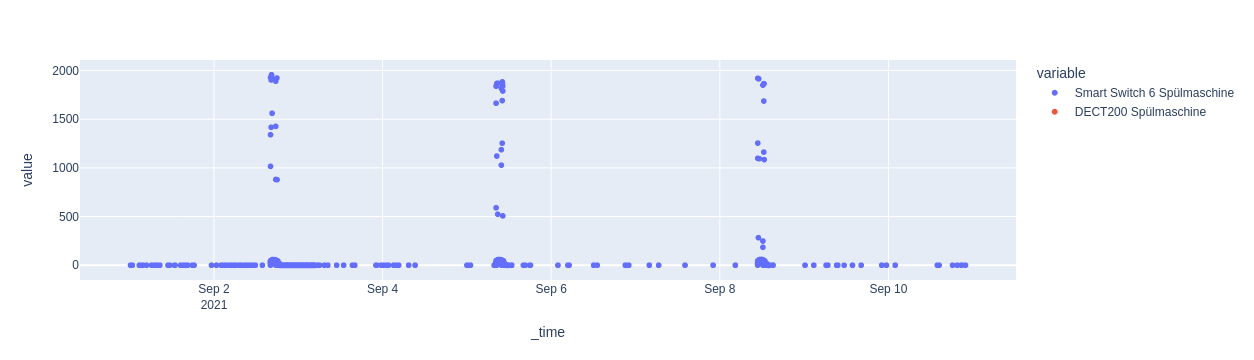

In [8]:
span = pd.Timedelta(10, "D")
start = pd.Timestamp(2021, 9, 1, tz="utc")
end = start + span

fig = px.scatter(sm.loc[start:end])
fig.show()